**ESPECIALIZAÇÃO EM COMUNICAÇÃO QUÂNTICA - SENAI CIMATEC**

Computação Quântica: Uma Abordagem Hands On

Adriane Martins Alves \
Caroline Da Silva Morais Alves



## Protocolo de Codificação Superdensa
Protocolo onde Alice transmite apenas um qubit para Bob, e com isso consegue efetivamente enviar dois bits clássicos de informação.


In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_distribution
import matplotlib.pyplot as plt

C:\Users\adria\AppData\Local\Temp\ipykernel_21128\1848513579.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister


: 

In [ ]:
pip install MatplotlibDrawer

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement MatplotlibDrawer (from versions: none)
ERROR: No matching distribution found for MatplotlibDrawer


## Execução dos comandos necessários para a construção do circuito:
Aqui foi demonstrado o circuito completo, ultilizando uma definição para quais bits classicos Alice quer enviar atráves de uma função de aleatoriedade, para que fossem demonstradas aleatopriamente a implementação do protocolo, abaixo foi explicado com mais detalhes esse processo.

In [ ]:
random_bit = QuantumRegister(1, "random bit")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
 
Alice_c = ClassicalRegister(1, "Alice c")
Alice_d = ClassicalRegister(1, "Alice d")
 
superdense_circuit = QuantumCircuit(random_bit, ebit0, ebit1, Alice_d, Alice_c)

# Trasmissor (Alice)
# Inicializa bits emaranhados
superdense_circuit.h(ebit0)
superdense_circuit.cx(ebit0, ebit1)
superdense_circuit.barrier()
 
# Mede os bits randômicos e armazena na variável clássica.
superdense_circuit.h(random_bit)
superdense_circuit.measure(random_bit, Alice_c)
superdense_circuit.h(random_bit)
superdense_circuit.measure(random_bit, Alice_d)
superdense_circuit.barrier()
 
# Alice manipula seu qbit baseado nos bits clássicos
# Codificação
with superdense_circuit.if_test((Alice_d, 1), label="Z"):
    superdense_circuit.z(ebit0)
with superdense_circuit.if_test((Alice_c, 1), label="X"):
    superdense_circuit.x(ebit0)
superdense_circuit.barrier()
 
# Receptor (Bob)
# Desfaz emaranhamento
superdense_circuit.cx(ebit0, ebit1)
superdense_circuit.h(ebit0)
superdense_circuit.barrier()

# Cria resgistradores e mede os valores enviados por Alice
Bob_c = ClassicalRegister(1, "Bob c")
Bob_d = ClassicalRegister(1, "Bob d")
superdense_circuit.add_register(Bob_d)
superdense_circuit.add_register(Bob_c)
superdense_circuit.measure(ebit0, Bob_d)
superdense_circuit.measure(ebit1, Bob_c)
 
display(superdense_circuit.draw(output="mpl"))

MissingOptionalLibraryError: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."

### Execução para diferentes shots.
A fim de observar esse circuito em pratica foi ultilizadoo simulador AerSimulator, para a produção da simulação dessas execuções.

Para demonstrar mais a fundo diferentes nuimeros de "Shots" ou quantidades de execução da simulação, foram feitos. 

É sempre importante lembrar que esas simulações são, para fim didatico, executadas em ambientes considerados sem ruido, por isso seus resultados são quase previsiveis, sendo que apresentam resultados divididos quase igualmente.

In [ ]:
shots = 1024

result = AerSimulator().run(superdense_circuit, shots=shots).result()
statistics = result.get_counts()

title = f"Superdense Coding — Shots = {shots}"

fig = plot_histogram(statistics, title=title)

ax = fig.axes[0]
ax.set_ylabel("Frequência")

display(fig)


TypeError: 'function' object is not iterable

In [ ]:
shots = 8192

result = AerSimulator().run(superdense_circuit, shots=shots).result()
statistics = result.get_counts()

title = f"Superdense Coding — Shots = {shots}"

fig = plot_histogram(statistics, title=title)

ax = fig.axes[0]
ax.set_ylabel("Frequência")

display(fig)

TypeError: 'function' object is not iterable

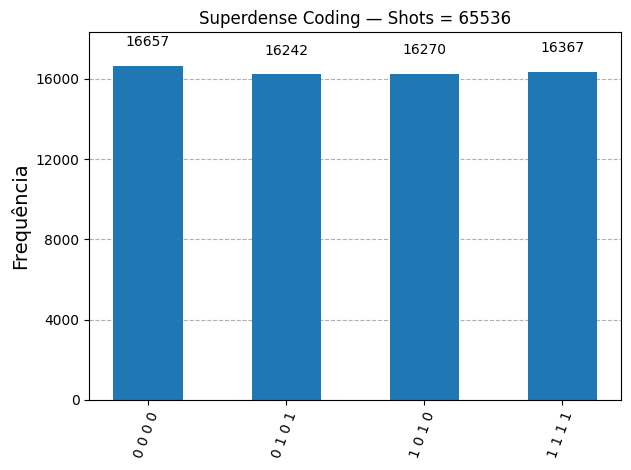

In [ ]:
shots = 65536

result = AerSimulator().run(superdense_circuit, shots=shots).result()
statistics = result.get_counts()

title = f"Superdense Coding — Shots = {shots}"

fig = plot_histogram(statistics, title=title)

ax = fig.axes[0]
ax.set_ylabel("Frequência")

display(fig)

### Códigos para exemplificação da teoria no relatório

## Estabelecendo o emaranhamento dos dois qubits, de Alice e Bob.
Esse processo acontece aplicando as portas Hadamar e CNOT no qubit de Alice, operação essa conhecida como **local** pois não produz nem destroi o emaranhamento estabelecido anterioremente entre o Transmissor e o Receptor.

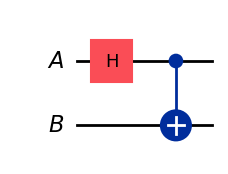

In [ ]:
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

superdense_circuit = QuantumCircuit(ebit0, ebit1)

superdense_circuit.h(ebit0)
superdense_circuit.cx(ebit0, ebit1)
display(superdense_circuit.draw(output="mpl"))

## Produzindo exemplos de envios feitos por Alice
Aqui foram definidos propositalmente quais os bits classicos Alice deseja enviar, a fim de demonstrar como que cada string desejada deve ter sua manipulação do estado de Alice para ser realizado.
É interessante observar como cada sequencia de bits diferente de (0,0) precisa da aplicação de uma porta X ou Z especifica, e em alguns casos ambas aplicadas, isso por que elas manipulam os bits de 0 para 1, quandoa ssim for necessário, sendo que cada porta modifica um dos "bits" de Alice (o primeiro ou o segundo) a fim de cumprir a necessidade de envio de informação.

In [ ]:
def superdense_circuit(c, d):
    ebit0 = QuantumRegister(1, "A")
    ebit1 = QuantumRegister(1, "B")

    sc = QuantumCircuit(ebit0, ebit1)

    sc.h(ebit0)
    sc.cx(ebit0, ebit1)
    sc.barrier()

    if d == "1":
        sc.z(ebit0)
    if c == "1":
        sc.x(ebit0)
    sc.barrier()

    sc.cx(ebit0, ebit1)
    sc.h(ebit0)

    cr = ClassicalRegister(2, "Bob")
    sc.add_register(cr)
    sc.measure(ebit0, cr[0])
    sc.measure(ebit1, cr[1])

    return sc

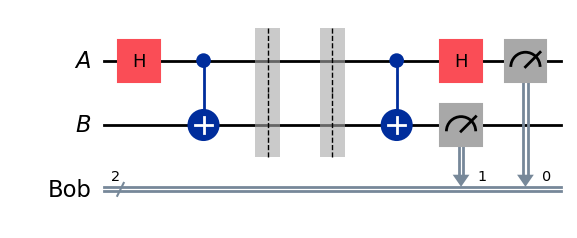

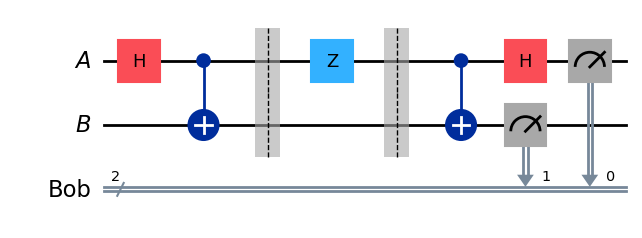

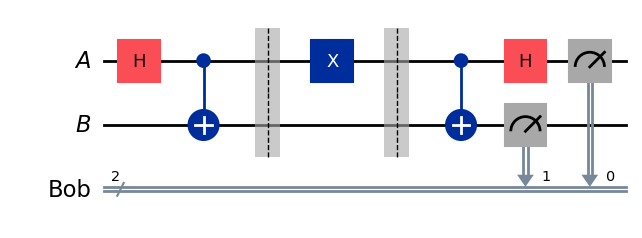

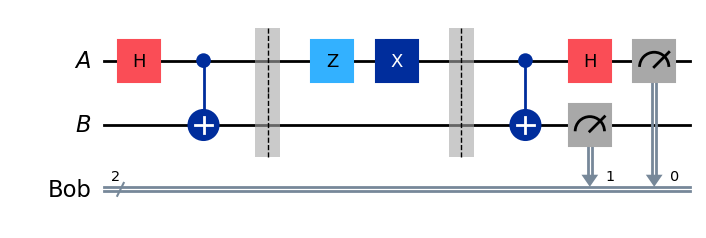

In [ ]:
c = "0"
d = "0"
display(superdense_circuit(c, d).draw("mpl"))

c = "0"
d = "1"
display(superdense_circuit(c, d).draw("mpl"))

c = "1"
d = "0"
display(superdense_circuit(c, d).draw("mpl"))

c = "1"
d = "1"
display(superdense_circuit(c, d).draw("mpl"))
